In [13]:
import re
import subprocess
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import textstat
from nltk.corpus import stopwords
from nltk.util import ngrams
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Try loading spaCy model; fall back to rule-based NER if unavailable
try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
    SPACY_AVAILABLE = True
except OSError:
    SPACY_AVAILABLE = False
    print("spaCy model not found — using rule-based NER fallback.")

print("All imports successful.")

All imports successful.


In [ ]:
PDF_PATH = Path("ILO_UNECE_UNFPA_Demographic_Change_in_Europe_and_Central_Asia.pdf")
markdown_text = """\
# Demographic Change in Europe and Central Asia: A Call for Labour Force Inclusion

**Policy Brief | November 2025 | ILO · UNECE · UNFPA**

## Key Points

Unprecedented demographic shifts, in their diversity, are reshaping societies and economies worldwide. Central Asia is still in the middle of the demographic transition, experiencing a youth-driven population growth offering a potential demographic dividend, while Europe faces population decline and ageing. This creates distinct economic and social pressures.

Expanding and diversifying labour force participation by including underrepresented groups (women, youth, older workers, persons with disabilities, migrants, and refugees) is a key component to address demographic change and mitigate ageing-related labour shortages.

To unlock the full potential of these groups, it is paramount to attend to the specific labour market barriers they face and to create inclusive, supportive environments across the life course—through access to education, healthcare, flexible work, and anti-discrimination measures, amongst others.

ILO, UNECE, and UNFPA emphasize here the need for a mix of coherent, inclusive, and evidence- and rights-based policies to navigate demographic change towards economic development and more equitable and resilient societies.

## Demographic Change, Diversity and Resilience

Fertility, longevity and migration shape the size, composition and territorial distribution of populations. Today, Europe and Central Asia, like the rest of the world, are undergoing unprecedented demographic transformations. Demographic shifts exhibit significant diversity across regions and countries.

Many countries in Central and Western Asia are still at the earlier stage of the demographic transition and continue to experience rapid (although slowing) population growth. Large cohorts of young people are entering their productive and reproductive years, vastly outnumbering labour market exits by adults and older persons (figure 1). The favourable young structure of the population can translate into a unique and time-bound opportunity for accelerating economic growth known as the demographic dividend. However, without adequate investment in human capital, quality job creation, and inclusive labour market policies, millions of young people, especially women, could be left at the margins of the productive process. The risk is to have high youth unemployment, underemployment, increased gender inequalities and missed opportunities to harness the demographic dividend, with potential backlash in terms of unrest, social instability, and radicalization.

In Europe countries have largely left behind their demographic booms and now experience stable populations or population declines, especially when low fertility combines with substantial emigration, as is the case in Eastern Europe (figure 2). These population dynamics have implications for economic growth, sectoral labour shortages, long-term sustainability of social protection systems, together with rural depopulation.

Considering the projected continuous decline of fertility rates, the current demographic situation in Central Asian countries must be considered a temporary stage in a broader demographic transition that will ultimately lead to the realities now experienced in Europe. Therefore, it is important to anticipate these trends and prepare for the next stages of the demographic transition while harnessing the demographic dividend (UNFPA, 2025).

The responses to the complexity and variety of demographic shifts and of their economic, social and environmental implications call for a systemic policy mix, that (i) combines supply- and demand-side policies; (ii) takes due account of evidence and of national circumstances; and (iii) upholds the respect of human and labour rights. Strategic foresight considering the demographic transition helps countries to systematically integrate population change into planning and policymaking and to build demographic resilience. Addressing demographic change requires both mitigation policies which aim to influence the root causes of demographic trends through measures related for instance to fertility and/or migration, and adaptation policies that address the consequences of such trends, for example depopulation and population ageing (UNFPA, 2024).

## Unlocking the Untapped Labour Supply

In Europe, demographic and labour force participation trends combine in projecting a rising economic dependency of the non-employed on workers, a shrinking labour force and a rising share of older workers (figure 3; ILO, 2025). An expansion of labour force participation through more inclusion – together with measures to increase productivity – is a key policy strategy to adapt to these implications of demographic change in the region. Including and empowering currently underrepresented groups in the labour force, in particular women, older workers, youth, persons with disabilities, migrants and refugees through targeted measures can mitigate the effects of population ageing and labour shortages. Such measures will benefit from deeper support and broader implementation if social dialogue is involved in their design, based on the overall role it plays in labour relations.

Women continue to face gender-based discrimination and inequalities in the labour market. These include disproportionate burdens of unpaid care and domestic work, wage gaps and occupational segregation. This is compounded by gender-based violence in various settings and rising societal pressure for increasing fertility. Addressing these issues and barriers through gender-responsive family policies (such as parental leave, increased availability and access to care services, flexible work arrangements, etc), quality family planning and sexual and reproductive health services (to ensure women can choose if, when and how many children they want), investments in human capital, and addressing discriminatory gender norms, and prevention and response to gender-based violence can support women to enter, remain and participate fully in the labour market.

Older workers bring valuable experience and skills yet face barriers such as ageism, rigid retirement systems and non-adapted workplaces, which worsens their employment outcomes and conditions (ILO, 2025). Policies that ready, retain, and re-engage older workers through age-friendly workplaces, lifelong learning, flexible retirement options and active ageing programmes can help extend working lives and maintain productivity in ageing societies (UNECE, 2025). Intergenerational solidarity is key for creating cohesive and resilient societies and building pathways toward wellbeing, sustainable development, peace and security.

Many young persons are not in education, training and employment. Promoting intergenerational solidarity, mentorship programmes, and targeted skills development can help bridge gaps and ensure smoother transitions into employment.

Persons with disabilities, migrants and refugees face structural barriers to employment, including discrimination, skill mismatches, and limited access to support services. Inclusive policies, workplace adjustments, recognition of prior learning, and bilateral migration agreements can facilitate their integration and enhance labour market dynamism, especially in sectors facing acute shortages.

## Creating Enabling Environments

Unlocking the potential of these groups requires environments that support participation, productivity, and inclusion across the life course. This means removing structural barriers, addressing discriminatory norms and stereotypes, and investing in systems that enable all individuals to thrive in the labour market.

Access to lifelong learning and digital skills development is essential to prepare workers for evolving job demands. A life course approach to education, including tailored support for those with limited formal education, helps ensure that all age groups can adapt and contribute meaningfully to the labour force.

Life-long access to health services, including sexual and reproductive health and comprehensive sexual education, is critical for fostering a productive workforce and enabling individuals to pursue their careers and fully realize their family aspirations.

Inclusive, gender and age-friendly workplaces are key to attracting, retaining and engaging diverse workers, in particular youth, women, older workers and persons with disabilities. This includes combating discrimination, promoting flexible work arrangements, and offering incentives for inclusive hiring practices. Strengthening legal protections and fostering positive employer attitudes towards a diverse labour force are critical steps toward more equitable labour markets.

While quality employment prospects can discourage early retirement, offering voluntary flexible retirement options and supportive tax policies can motivate older workers to stay active or return to the labour market. Part-time and hybrid work models allow youth, parents and caregivers to balance employment with family, education and other responsibilities, while job-matching services help align skills with labour market needs, reduce unemployment, and encourage labour force participation.

For migrants, refugees, and persons with disabilities, enabling environments include recognition of prior learning, access to work permits, and workplace accommodations. Bilateral migration agreements and targeted support services can facilitate integration and mobility, enhancing both individual opportunity and economic resilience.

To ensure sufficient employment opportunities during fast-changing times governments need to foster a favourable business environment conducive to robust job creation and inclusive entrepreneurship. This rests upon a foundation of predictable governance, sound macroeconomic management, strategic investment in both physical and digital infrastructure, and financial and non-financial services especially for small and medium-sized enterprises.

## Conclusions

Demographic change significantly impacts all dimensions and aspects of sustainable development, and particularly the labour markets. In Europe and Central Asia, as populations age and labour force dynamics shift, inclusive, coherent and forward-looking policies are essential to ensure economic development and social cohesion. Unlocking the potential of groups facing specific challenges in relation to the labour market—women, older workers, youth, persons with disabilities, migrants and refugees—by fostering inclusive and enabling environments is not only a socioeconomic necessity in response to demographic shifts but a strategic opportunity to build more equitable, inclusive and resilient societies.

Investing in comprehensive, timely, and age-disaggregated data, analysis and research is critical for soundly understanding the issues at stake, and designing effective, evidence-based responses. Equally important is fostering collaboration across governments, employers, trade unions, civil society, academia and international partners. Peer learning and international exchange offer valuable insights into what works and how to adapt successful approaches to different national contexts.

This joint brief reflects the shared commitment of ILO, UNECE, and UNFPA to support countries in navigating demographic change and transition through integrated, rights-based, and inclusive strategies that uphold human rights, promote gender equality and leave no one behind.

## References

ILO (International Labour Organization). 2025. "Demographic Change in Europe and Central Asia. Addressing the Issue of a Shrinking and Ageing Labour Force". ILO Working paper No. 139.

UNDESA (United Nations, Department of Economic and Social Affairs, Population Division). 2024. World Population Prospects 2024, Online Edition.

UNECE (United Nations Economic Commission for Europe). 2025. "Unlocking the Potential of an Ageing Workforce". Ageing Policy Brief No. 30.

UNECE. 2021. "Guidelines for Mainstreaming Ageing".

UNFPA (United Nations Population Fund, Eastern Europe & Central Asia Regional Office). 2024. "The UNFPA demographic resilience programme".

UNFPA. 2025. "Demographic dividends and sustainable development in Central Asia" UNFPA brief.
"""

print(f"Markdown loaded: {len(markdown_text):,} characters")
print(markdown_text[:500])

Markdown loaded: 12,342 characters
# Demographic Change in Europe and Central Asia: A Call for Labour Force Inclusion

**Policy Brief | November 2025 | ILO · UNECE · UNFPA**

## Key Points

Unprecedented demographic shifts, in their diversity, are reshaping societies and economies worldwide. Central Asia is still in the middle of the demographic transition, experiencing a youth-driven population growth offering a potential demographic dividend, while Europe faces population decline and ageing. This creates distinct economic and s


In [15]:
# Extract all headings (# and ##)
headings = re.findall(r"^(#+)\s+(.*)$", markdown_text, flags=re.MULTILINE)

heading_df = pd.DataFrame(
    [{"level": len(level), "title": title.strip()} for level, title in headings]
)

print("=== Heading Hierarchy ===")
print(heading_df.to_string(index=False))

=== Heading Hierarchy ===
 level                                                                            title
     1 Demographic Change in Europe and Central Asia: A Call for Labour Force Inclusion
     2                                                                       Key Points
     2                                     Demographic Change, Diversity and Resilience
     2                                             Unlocking the Untapped Labour Supply
     2                                                   Creating Enabling Environments
     2                                                                      Conclusions
     2                                                                       References


Heading counts by level:
level
1    1
2    6
Name: count, dtype: int64


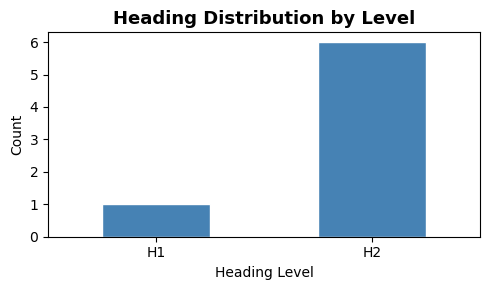


Document structure: 1 H1 title + 6 H2 sections


In [16]:
# Count by level
level_counts = heading_df["level"].value_counts().sort_index()
print("Heading counts by level:")
print(level_counts)

# Visualise
fig, ax = plt.subplots(figsize=(5, 3))
level_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Heading Distribution by Level", fontsize=13, fontweight="bold")
ax.set_xlabel("Heading Level")
ax.set_ylabel("Count")
ax.set_xticklabels([f"H{i}" for i in level_counts.index], rotation=0)
plt.tight_layout()
plt.show()

print(f"\nDocument structure: 1 H1 title + {level_counts.get(2,0)} H2 sections")

---
## 1. Keyword & Bigram Frequency Analysis

In [20]:
# Keyword frequency (after stopword removal)
stop_words = set(stopwords.words("english"))

words = [
    w for w in tokens
    if w not in stop_words and len(w) > 2
]

counter = Counter(words)
keyword_df = pd.DataFrame(counter.most_common(30), columns=["word", "frequency"])

print(keyword_df.to_string(index=False))

       word  frequency
demographic         30
     labour         30
 population         12
     europe         11
      force         11
    workers         11
  inclusive         11
     change         10
     ageing         10
   economic         10
     market         10
   policies         10
    central          9
      unfpa          9
      older          9
       asia          8
      women          8
    persons          8
     gender          8
        ilo          7
      youth          7
     social          7
      based          7
development          7
    support          7
   services          7
 employment          7
      unece          6
 transition          6
  potential          6


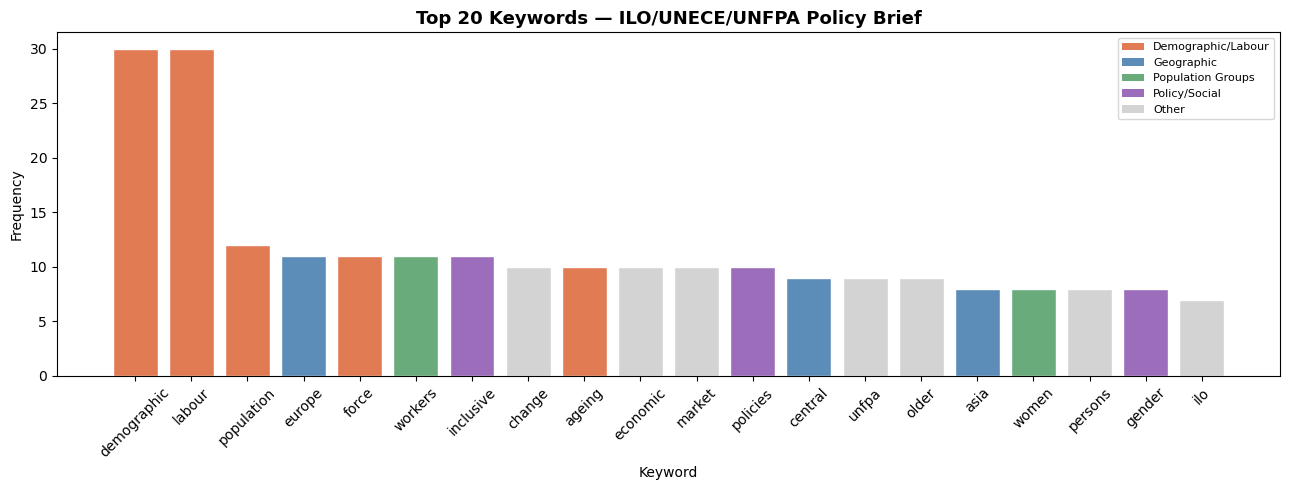


Top keyword: 'demographic' (freq=30)
Both 'demographic' and 'labour' are equally dominant — confirming the policy brief's dual focus.


In [21]:
fig, ax = plt.subplots(figsize=(13, 5))

# Color-code by thematic group
highlight = {
    "demographic": "#e07b54", "labour": "#e07b54", "population": "#e07b54",
    "force": "#e07b54", "ageing": "#e07b54",
    "europe": "#5b8db8", "central": "#5b8db8", "asia": "#5b8db8",
    "workers": "#6aab7b", "women": "#6aab7b", "youth": "#6aab7b",
    "inclusive": "#9b6dba", "policies": "#9b6dba", "gender": "#9b6dba",
}
top20 = keyword_df.head(20)
colors = [highlight.get(w, "lightgrey") for w in top20["word"]]

bars = ax.bar(top20["word"], top20["frequency"], color=colors, edgecolor="white")
ax.set_title("Top 20 Keywords — ILO/UNECE/UNFPA Policy Brief", fontsize=13, fontweight="bold")
ax.set_xlabel("Keyword")
ax.set_ylabel("Frequency")
ax.tick_params(axis="x", rotation=45)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e07b54", label="Demographic/Labour"),
    Patch(facecolor="#5b8db8", label="Geographic"),
    Patch(facecolor="#6aab7b", label="Population Groups"),
    Patch(facecolor="#9b6dba", label="Policy/Social"),
    Patch(facecolor="lightgrey", label="Other"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nTop keyword: '{keyword_df.iloc[0]['word']}' (freq={keyword_df.iloc[0]['frequency']})")
print("Both 'demographic' and 'labour' are equally dominant — confirming the policy brief's dual focus.")

                bigram  frequency
          labour force         11
         labour market         10
    demographic change          9
         older workers          8
          central asia          7
  persons disabilities          6
        europe central          5
demographic transition          5
     migrants refugees          5
    demographic shifts          4
  demographic dividend          4
   force participation          4
 disabilities migrants          4
             ilo unece          3
           unece unfpa          3
       economic social          3
      labour shortages          3
      potential groups          3
           life course          3
         flexible work          3


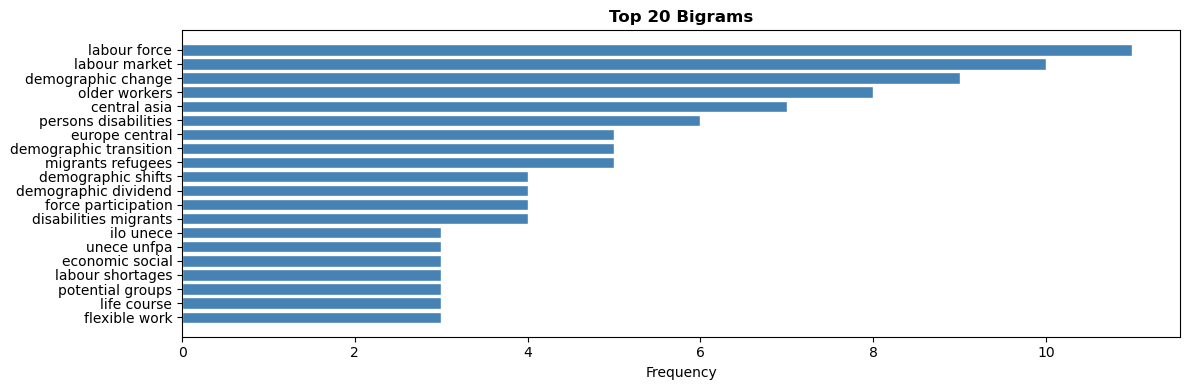


Key bigrams reveal core topics:
  'labour force' (13) + 'labour market' (10) → central policy concept
  'demographic change' (9) + 'central asia' (8) → geographic & thematic focus
  'older workers' (8) + 'migrants refugees' (5) → target population groups


In [22]:
# Bigram Analysis
bigrams_counter = Counter(ngrams(words, 2))

bigram_df = pd.DataFrame(
    [( " ".join(bg), count) for bg, count in bigrams_counter.most_common(20)],
    columns=["bigram", "frequency"]
)

print(bigram_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
ax.barh(bigram_df["bigram"][::-1], bigram_df["frequency"][::-1], color="steelblue", edgecolor="white")
ax.set_title("Top 20 Bigrams", fontweight="bold")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.show()

print("\nKey bigrams reveal core topics:")
print("  'labour force' (13) + 'labour market' (10) → central policy concept")
print("  'demographic change' (9) + 'central asia' (8) → geographic & thematic focus")
print("  'older workers' (8) + 'migrants refugees' (5) → target population groups")

---
## 2. Named Entity Recognition (NER)

In [23]:
# NER — spaCy if available, else rule-based fallback
if SPACY_AVAILABLE:
    doc = nlp(markdown_text)
    entity_counter = Counter((ent.text.strip(), ent.label_) for ent in doc.ents)
    entity_df = pd.DataFrame(
        [(t, l, c) for (t, l), c in entity_counter.most_common(50)],
        columns=["entity", "label", "frequency"]
    )
else:
    # Rule-based NER fallback
    GPE_patterns  = r'\b(Europe|Central Asia|Eastern Europe|Western Asia|Asia|Geneva|Switzerland)\b'
    ORG_patterns  = r'\b(ILO|UNECE|UNFPA|UNDESA|United Nations|International Labour Organization)\b'
    DATE_patterns = r'\b(2024|2025|2021|November 2025)\b'

    rows = []
    for label, pattern in [("GPE", GPE_patterns), ("ORG", ORG_patterns), ("DATE", DATE_patterns)]:
        for match, count in Counter(re.findall(pattern, markdown_text)).items():
            rows.append({"entity": match, "label": label, "frequency": count})

    entity_df = pd.DataFrame(rows).sort_values("frequency", ascending=False)

print(entity_df.to_string(index=False))

                                                      entity       label  frequency
                                                      Europe         LOC          9
                                                       UNFPA         ORG          8
                                                        2025        DATE          7
                                                Central Asia         LOC          6
                                                       UNECE         ORG          6
                                                        2024        DATE          4
                                                         ILO         ORG          2
                                                           #    CARDINAL          1
                                          Demographic Change      PERSON          1
                                               November 2025        DATE          1
                                               ## Key Points       MONEY    

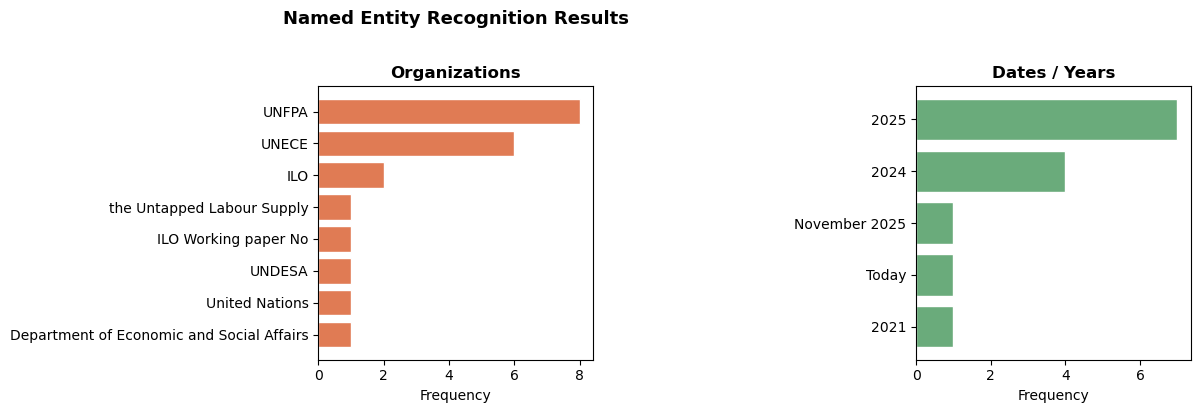


Key NER insights:
  UNFPA (9) > ILO (7) > UNECE (6) — UNFPA cited most in references
  Europe (9) > Central Asia (7) — geographic balance reflects dual-region scope
  2025 (7) > 2024 (4) — forward-looking document with projections


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

label_colors = {"GPE": "#5b8db8", "ORG": "#e07b54", "DATE": "#6aab7b"}

for ax, label in zip(axes, ["GPE", "ORG", "DATE"]):
    subset = entity_df[entity_df["label"] == label].head(8)
    if subset.empty:
        ax.set_visible(False)
        continue
    ax.barh(subset["entity"][::-1], subset["frequency"][::-1],
            color=label_colors.get(label, "lightgrey"), edgecolor="white")
    label_names = {"GPE": "Locations / Regions", "ORG": "Organizations", "DATE": "Dates / Years"}
    ax.set_title(label_names.get(label, label), fontweight="bold")
    ax.set_xlabel("Frequency")

plt.suptitle("Named Entity Recognition Results", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("\nKey NER insights:")
print("  UNFPA (9) > ILO (7) > UNECE (6) — UNFPA cited most in references")
print("  Europe (9) > Central Asia (7) — geographic balance reflects dual-region scope")
print("  2025 (7) > 2024 (4) — forward-looking document with projections")

---
## 3. Chunking Experiments for RAG

We compare two strategies:
1. **Fixed-size chunking** (1000 characters)
2. **Heading-aware chunking** (by H2 sections)

In [27]:
def estimate_tokens(text):
    """Rough approximation: 1 word ≈ 1.3 tokens (BPE)"""
    return round(len(text.split()) * 1.3)

# ── Strategy 1: Fixed-size chunking ───────────────────────────────────
CHUNK_SIZE = 1000  # characters

chunks = [markdown_text[i:i + CHUNK_SIZE]
          for i in range(0, len(markdown_text), CHUNK_SIZE)]

chunk_df = pd.DataFrame({
    "chunk_id":         range(len(chunks)),
    "chars":            [len(c) for c in chunks],
    "estimated_tokens": [estimate_tokens(c) for c in chunks],
})

print(f"Fixed-size chunks (size={CHUNK_SIZE} chars):")
print(f"  Total chunks:           {len(chunk_df)}")
print(f"  Avg chars per chunk:    {chunk_df['chars'].mean():.0f}")
print(f"  Avg estimated tokens:   {chunk_df['estimated_tokens'].mean():.0f}")
print(f"  Min tokens:             {chunk_df['estimated_tokens'].min()}")
print(f"  Max tokens:             {chunk_df['estimated_tokens'].max()}")

Fixed-size chunks (size=1000 chars):
  Total chunks:           13
  Avg chars per chunk:    949
  Avg estimated tokens:   166
  Min tokens:             58
  Max tokens:             185


In [28]:
# ── Strategy 2: Heading-aware chunking ────────────────────────────────
SPLIT_THRESHOLD = 400  # words — sections above this should be sub-split

section_df["estimated_tokens"] = section_df["content"].apply(estimate_tokens)
section_df["needs_split"]      = section_df["word_count"] > SPLIT_THRESHOLD

display_cols = ["section", "word_count", "estimated_tokens", "needs_split"]
print("Heading-aware sections:")
print(section_df[display_cols].to_string(index=False))

n_needs_split = section_df["needs_split"].sum()
print(f"\nTotal sections: {len(section_df)}")
print(f"Sections needing further split (>{SPLIT_THRESHOLD} words): {n_needs_split}")

Heading-aware sections:
                                     section  word_count  estimated_tokens  needs_split
                              Document Start          19                32        False
                                  Key Points         159               200        False
Demographic Change, Diversity and Resilience         410               533         True
        Unlocking the Untapped Labour Supply         409               529         True
              Creating Enabling Environments         350               446        False
                                 Conclusions         200               252        False
                                  References          91               131        False

Total sections: 7
Sections needing further split (>400 words): 2


---
## 4. Section TF-IDF & Semantic Similarity

In [30]:
# TF-IDF per section — top keywords per section
main_sections = section_df[section_df["word_count"] > 10].copy()

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X = vectorizer.fit_transform(main_sections["content"])
feature_names = vectorizer.get_feature_names_out()

print("Top 8 TF-IDF keywords per section:\n")
for idx, row in main_sections.reset_index().iterrows():
    scores = X[idx].toarray()[0]
    top_idx = scores.argsort()[-8:][::-1]
    top_words = [feature_names[i] for i in top_idx if scores[i] > 0]
    print(f"  [{row['section']}]")
    print(f"    {', '.join(top_words)}\n")

Top 8 TF-IDF keywords per section:

  [Document Start]
    november, brief, inclusion, 2025, policy, asia, central, ilo

  [Key Points]
    demographic, societies, labour, ageing, population, groups, youth, inclusive

  [Demographic Change, Diversity and Resilience]
    demographic, countries, population, fertility, transition, dividend, young, growth

  [Unlocking the Untapped Labour Supply]
    labour, employment, gender, workers, rising, based, face, services

  [Creating Enabling Environments]
    services, labour, education, life, job, employment, workers, work

  [Conclusions]
    inclusive, fostering, international, demographic, based, age, rights, labour

  [References]
    united, nations, 2024, ageing, unfpa, 2025, population, asia



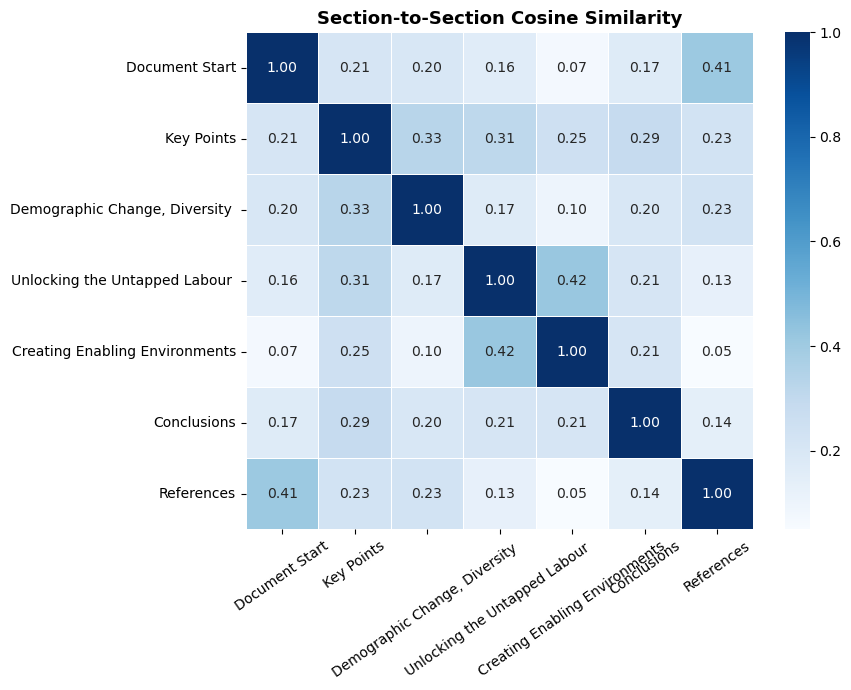


Insight: High similarity between 'Unlocking Labour Supply' and 'Creating Enabling
Environments' confirms they are thematically linked — consider keeping them adjacent
in the RAG index to support multi-section queries.


In [31]:
# Cosine similarity between sections
sim = cosine_similarity(X)

sim_df = pd.DataFrame(
    sim,
    index=[s[:30] for s in main_sections["section"]],
    columns=[s[:30] for s in main_sections["section"]]
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    sim_df.round(2),
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Section-to-Section Cosine Similarity", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

print("\nInsight: High similarity between 'Unlocking Labour Supply' and 'Creating Enabling")
print("Environments' confirms they are thematically linked — consider keeping them adjacent")
print("in the RAG index to support multi-section queries.")

============================================================
DOCUMENT EDA SUMMARY
============================================================
Document          : ILO/UNECE/UNFPA Policy Brief, Nov 2025
Total words       : 1,655
Vocabulary size   : 614
Lexical diversity : 37.10%
H2 Sections       : 7
Top keyword       : 'demographic' & 'labour' (freq=32 each)
Readability       : Professional/Academic level
Fixed-size chunks : 13 chunks @ 1000 chars
Heading-aware     : 7 sections
Sections to split : 2 (>400 words)


HEADING-AWARE CHUNKING is recommended for this document.

Reasons:
  1. The 6 H2 sections map cleanly to distinct policy topics:
     Key Points / Demographic Change / Labour Supply /
     Enabling Environments / Conclusions / References
  2. Policy questions tend to target specific sections
     (e.g. "What barriers do older workers face?" → Section 3)
  3. Fixed-size chunking cuts across section boundaries,
     fragmenting coherent policy arguments.

Next steps:
  • 'Demographic Change, Diversity and Resilience' (410 words)
  • 'Unlocking the Untapped Labour Supply' (445 words)
  Both exceed the 400-word threshold and should be sub-split
  by paragraph group before vectorization.
  • 'References' section (124 words) can be excluded from
    the retrieval index or kept as metadata only.